In [5]:
import utils_inverse
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import pickle
from cmcrameri import cm
import jax
import utils_plotting
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plot supplemental data

In [6]:
def plot_comparison_results(
    result_paths,
    column_titles,
    baseline_errors,                 # List of floats, one per dataset (dashed lines)
    active_agents=None,              # Filter for agents
    agent_units=None,                # {'CO2':'GtCO₂/yr', ...}
    max_lines=11,
    save_path=None
):
    """
    Comparison plot for multiple datasets.
    Columns = Datasets (defined by result_paths)
    Rows    = 1 (NRMSE) + N (Agents)

    Args:
        result_paths: List of file paths to pickle files containing 'results'.
        column_titles: List of strings for the text box in each column (top left).
        baseline_errors: List of baseline error values corresponding to each path.
    """

    # --- 1. Load Data ---
    loaded_results = []
    for path in result_paths:
        with open(path, 'rb') as f:
            loaded_results.append(pickle.load(f))

    n_cols = len(loaded_results)
    if len(column_titles) != n_cols:
        raise ValueError("Length of column_titles must match result_paths.")
    if len(baseline_errors) != n_cols:
        raise ValueError("Length of baseline_errors must match result_paths.")

    # --- 2. Helpers (Internal) ---
    def _agents_in_state(state):
        if isinstance(state, (tuple, list)) and len(state) == 2:
            return ("CO2", "CH4")
        if isinstance(state, dict):
            return tuple(state.keys())
        raise ValueError("Unrecognized U_traj state format.")

    def _get_series(state, agent):
        if isinstance(state, (tuple, list)):
            if agent == "CO2": return jnp.asarray(state[0]).reshape(-1)
            if agent == "CH4": return jnp.asarray(state[1]).reshape(-1)
            raise KeyError(f"Agent {agent} not found in tuple state.")
        return jnp.asarray(state[agent]).reshape(-1)

    # --- 3. Determine Layout based on First Dataset ---
    # (Assumes all datasets have roughly consistent agents, or uses active_agents to filter)
    first_res = loaded_results[0]
    present_agents = _agents_in_state(first_res["U_traj"][0])

    if active_agents is None:
        active_agents = present_agents
    else:
        active_agents = tuple(a for a in active_agents if a in present_agents)

    if agent_units is None:
        agent_units = {"CO2": "Gt/yr", "CH4": "Mt/yr", "N2O": "Mt/yr", "Sulfur":"Mt/yr", "BC": "Mt/yr"}

    n_agents = len(active_agents)
    n_rows = 1 + n_agents  # 1 for NRMSE, N for agents

    # Calculate T (time) from the first dataset/first agent to set x-limits
    # (Assumes all datasets span the same timeframe, which is standard for comparisons)
    probe_agent = active_agents[0] if len(active_agents) > 0 else present_agents[0]
    T = int(_get_series(first_res["U_traj"][-1], probe_agent).shape[0])

    # --- 4. Create Subplots ---
    fig_height = 2.5 * n_rows
    fig_width = 4.0 * n_cols

    # sharey='row' ensures all NRMSE plots share scale, and all CO2 plots share scale, etc.
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols,
        figsize=(fig_width, fig_height),
        sharey='row',
        sharex='row',
        constrained_layout=True
    )

    # Ensure axes is always 2D array [row, col] even if n_cols=1 or n_rows=1
    if n_cols == 1:
        axes = axes[:, np.newaxis]
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    # --- 5. Plotting Loop ---
    for col_idx, results in enumerate(loaded_results):

        errors = jnp.asarray(results["errors"])
        U_traj = results["U_traj"]
        n_update_steps = int(results.get("updates_done", max(0, errors.shape[0] - 1)))

        # --- Row 0: NRMSE ---
        ax_err = axes[0, col_idx]
        x_err = jnp.arange(errors.shape[0])

        ax_err.loglog(x_err, errors, c=cm.batlowWS(1), label="Optimized emulator")
        ax_err.axhline(float(baseline_errors[col_idx]), ls="--", c=cm.lipariS(5), lw=1.5, label="Baseline emulator\nerror lower bound")

        ax_err.set_xlim(0, n_update_steps)
        if col_idx == 0:
            ax_err.set_ylabel("NRMSE")

        # Add the text box (Dataset Title) to the top plot of the column
        ax_err.text(
            0.03, 0.95, column_titles[col_idx], transform=ax_err.transAxes,
            ha="left", va="top", fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
        )
        ax_err.grid(True, alpha=0.3)
        if col_idx == 0:
            ax_err.legend(loc="upper right", fontsize=9)

        # --- Rows 1..N: Emissions ---
        n_total = len(U_traj)
        if n_total <= max_lines:
            sel_steps = np.arange(n_total, dtype=int)
        else:
            sel_steps = np.unique(np.linspace(0, n_total - 1, num=max_lines, dtype=int))

        for row_offset, ag in enumerate(active_agents):
            row_idx = 1 + row_offset
            ax_curr = axes[row_idx, col_idx]

            has_any = False
            for i in sel_steps:
                state = U_traj[i]
                # Check if this agent exists in this specific dataset's state
                # (Handles cases where datasets might have slightly different agent keys)
                try:
                    series = _get_series(state, ag)
                    alpha = 0.2 + 0.6 * (i / max(1, len(U_traj) - 1))
                    if i in [0, 100, 1000]:
                        if i == 0:
                            c = cm.lipariS(5)
                            alpha = 1
                        else:
                            c = cm.batlowWS(1)
                        ax_curr.plot(series, alpha=alpha, c=c, label=f"Step {i}")
                    else:
                        ax_curr.plot(series, alpha=alpha, c=cm.batlowWS(1))
                    has_any = True
                except KeyError:
                    continue

            ax_curr.set_xlim(0, T)
            ax_curr.grid(True, alpha=0.3)

            # Label Y-axis only for the first column
            if col_idx == 0:
                unit = agent_units.get(ag, "units/yr")
                ax_curr.set_ylabel(f"{ag} ({unit})")

            # Add Legend only on the first agent plot of the first column to avoid clutter
            if col_idx == 0 and row_offset == 0 and has_any:
                ax_curr.legend(fontsize=8, loc="lower left")

        # Set X-label on the bottom-most plot of this column
        axes[-1, col_idx].set_xlabel("Year")

    if save_path is not None:
        plt.savefig(f'Figures/{save_path}.pdf')

    return

In [68]:
baseline_path = 'checkpoints/co2/baseline_co2_only.pkl'
with open(baseline_path, 'rb') as f:
  baseline_results = pickle.load(f)

In [113]:
IC_list = ['constant','gaussian','sine']
result_paths = [f'data/SI_results/sensitivity_initial_condition/inverse_{IC}_co2_only.pkl' for IC in IC_list]
column_titles = ['(a) Constant', '(b) Gaussian', '(c) Sinusoid']
baseline_errors = [baseline_results['All']['mean'] for i in range(len(IC_list))]

/var/folders/5v/9rw_h5d56d57jgsmbk2dfb980000gn/T/ipykernel_74462/833745056.py:102: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_err.set_xlim(0, n_update_steps)


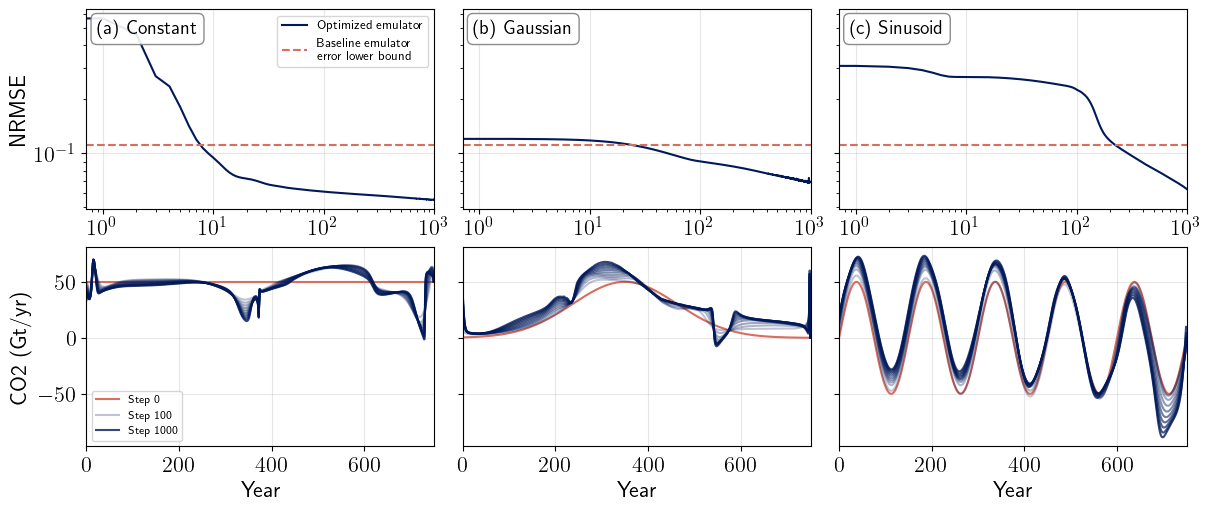

In [114]:
plot_comparison_results(
    result_paths,
    column_titles,
    baseline_errors,
    active_agents=("CO2",),
    save_path=None)#'SI_IC')

In [2]:
arch_list = ['8','16','32','16_16']
baseline_paths = [f'data/SI_results/sensitivity_architecture/baseline_{arch}_co2_only.pkl' for arch in arch_list]
baseline_errors = []
for path in baseline_paths:
  with open(path, 'rb') as f:
    res = pickle.load(f)
  baseline_errors.append(res['All']['mean'])

In [8]:
IC = 'sine'
result_paths = [f'data/SI_results/sensitivity_architecture/inverse_{arch}_co2_only_{IC}_test.pkl' for arch in arch_list]
column_titles = ['(a) [8]', '(b) [16]', '(c) [32]', '(d) [16, 16]']

/var/folders/5v/9rw_h5d56d57jgsmbk2dfb980000gn/T/ipykernel_85208/833745056.py:102: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_err.set_xlim(0, n_update_steps)


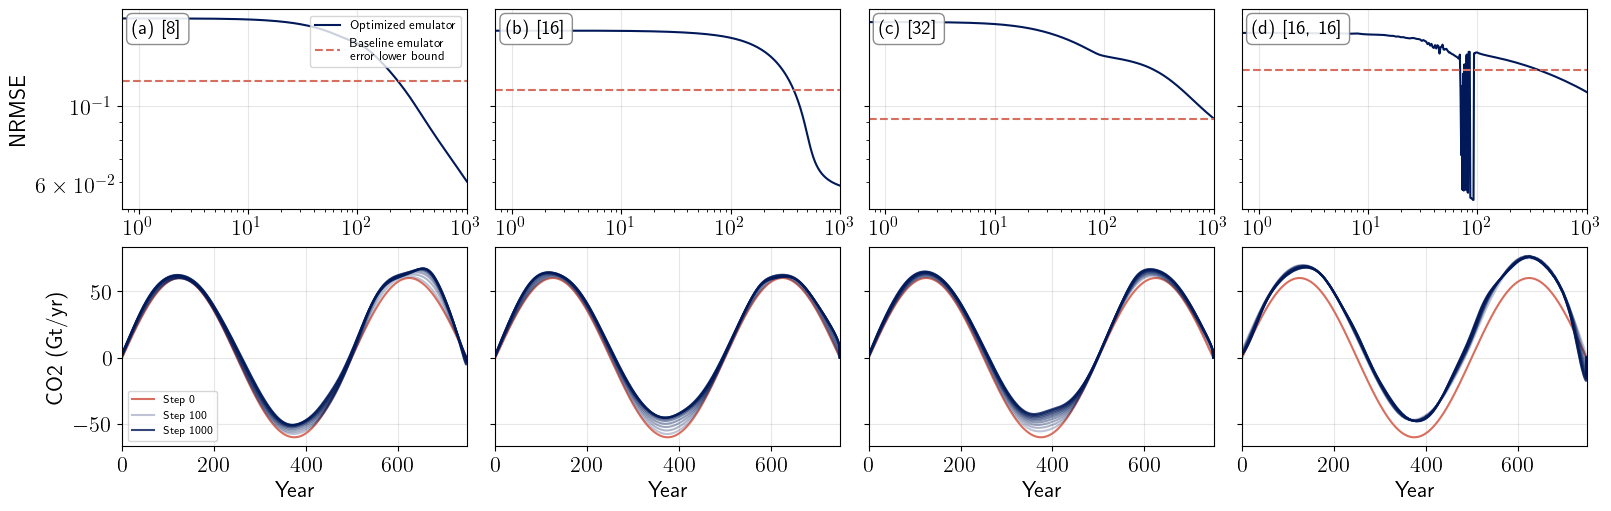

In [10]:
plot_comparison_results(
    result_paths,
    column_titles,
    baseline_errors,
    active_agents=("CO2",),
    save_path='SI_arch_sine')

In [135]:
feat_list = ['short','medium','long']
baseline_paths = [f'data/SI_results/sensitivity_features/baseline_{feat}_co2_only.pkl' for feat in feat_list]
baseline_errors = []
for path in baseline_paths:
  with open(path, 'rb') as f:
    res = pickle.load(f)
  baseline_errors.append(res['All']['mean'])

In [144]:
IC = 'sine'
result_paths = [f'data/SI_results/sensitivity_features/inverse_{feat}_co2_only_{IC}.pkl' for feat in feat_list]
column_titles = ['(a) Short', '(b) Medium', '(c) Long']

/var/folders/5v/9rw_h5d56d57jgsmbk2dfb980000gn/T/ipykernel_74462/833745056.py:102: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_err.set_xlim(0, n_update_steps)


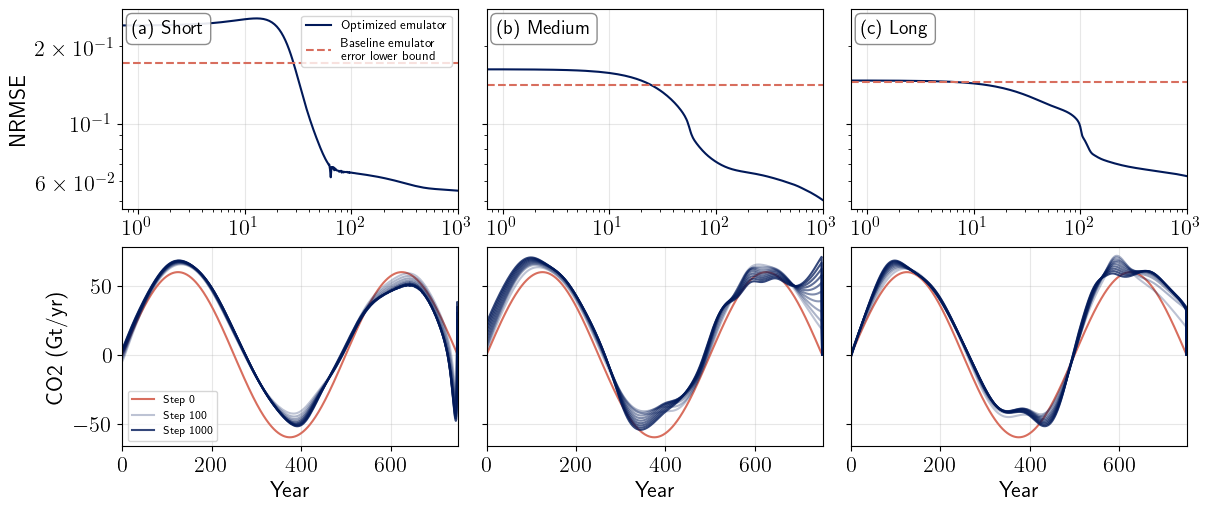

In [145]:
plot_comparison_results(
    result_paths,
    column_titles,
    baseline_errors,
    active_agents=("CO2",),
    save_path=f'SI_feat_{IC}')

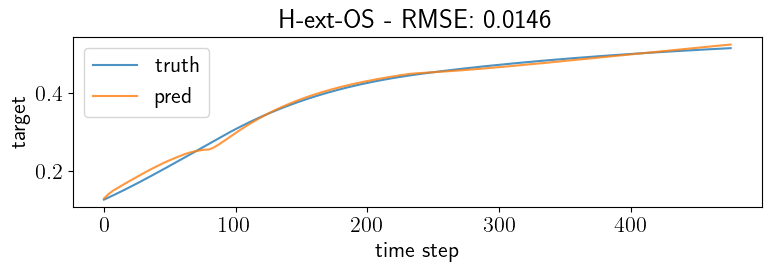

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.0
	||grad N2O||: 0.0004070528957527131
	||grad Sulfur||: 0.0


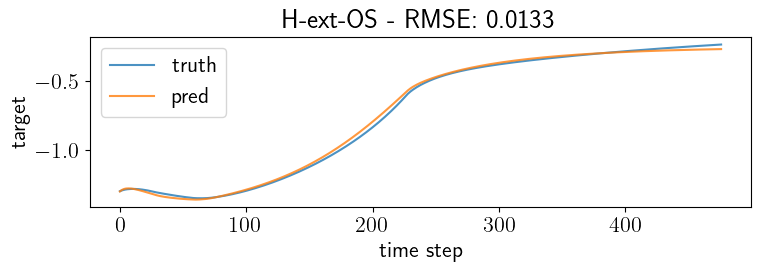

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.0
	||grad N2O||: 0.0
	||grad Sulfur||: 9.062967365025543e-06


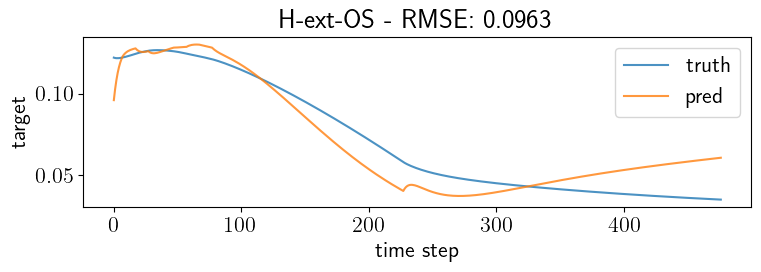

Getting gradient for historical...
	||grad BC||: 0.0008296993328258395
	||grad CH4||: 0.0
	||grad CO2||: 0.0
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [85]:
# Required to generate baseline parameters
agent_list = ['N2O','Sulfur','BC']
agent_lower_list = ['n2o','Sulfur','BC']
for agent, agent_lower in zip(agent_list, agent_lower_list):
  agents        = [agent]       # Forcing agents included in temperatutre simulations
  active_agents = (agent,)      # Forcing agents with active gradients (can differ from above)
  hidden_sizes  = [16]          # Dimension of neural network emulator
  idx_demo      = 1             # Index of scenario to plot
  test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
  verbose       = False         # Flag to print RMSE values for test

  # Generate initial parameters and test backpropagation
  params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                  active_agents,
                                                                                  test_scen,
                                                                                  hidden_sizes=hidden_sizes,
                                                                                  idx_demo=idx_demo,
                                                                                  verbose=verbose)

  (eval_sets,
  emis_dict_tier1_JAX,
  emis_dict_tier2_JAX,
  emis_dict_DECK_JAX,
  emis_dict_CS3_JAX,
  emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

  training_paths = [f'checkpoints/{agent_lower}/inverse_constant_tier1_{agent_lower}_only.pkl',
                    f'checkpoints/{agent_lower}/inverse_constant_tier2_{agent_lower}_only.pkl',
                    f'checkpoints/{agent_lower}/inverse_constant_DECK_{agent_lower}_only.pkl',
                    f'checkpoints/{agent_lower}/inverse_constant_CS3_{agent_lower}_only.pkl',
                    f'checkpoints/{agent_lower}/inverse_constant_all_{agent_lower}_only.pkl']

  train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. All']
  optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    train_scenarios=train_scenarios,
    eval_sets=eval_sets,
    params0=params0,
    active_agents=active_agents,
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
  )

  save_path = f'data/SI_results/extended_results/optimal_{agent_lower}_only.pkl'
  with open(save_path, "wb") as f:
    pickle.dump(optimal_results, f)


In [97]:
agent_lower_list = ['co2','ch4','n2o','Sulfur','BC']
baseline_results_list, optimal_results_list = [], []
for agent_lower in agent_lower_list:
    baseline_path_all = f'data/SI_results/extended_results/baseline_{agent_lower}_only.pkl'
    with open(baseline_path_all, 'rb') as file:
        baseline_results_list.append(pickle.load(file))

    optimal_path_all = f'data/SI_results/extended_results/optimal_{agent_lower}_only.pkl'
    with open(optimal_path_all, 'rb') as file:
        optimal_results_list.append(pickle.load(file))


In [96]:
for agent_lower in agent_lower_list[1:]:
    optimal_path_all = f'data/SI_results/extended_results/optimal_{agent_lower}_only.pkl'
    with open(optimal_path_all, 'rb') as file:
        res = pickle.load(file)

    res['Opt. CS3'] = res.pop('Opt CS3')
    save_path = f'data/SI_results/extended_results/optimal_{agent_lower}_only.pkl'
    with open(save_path, "wb") as f:
        pickle.dump(res, f)

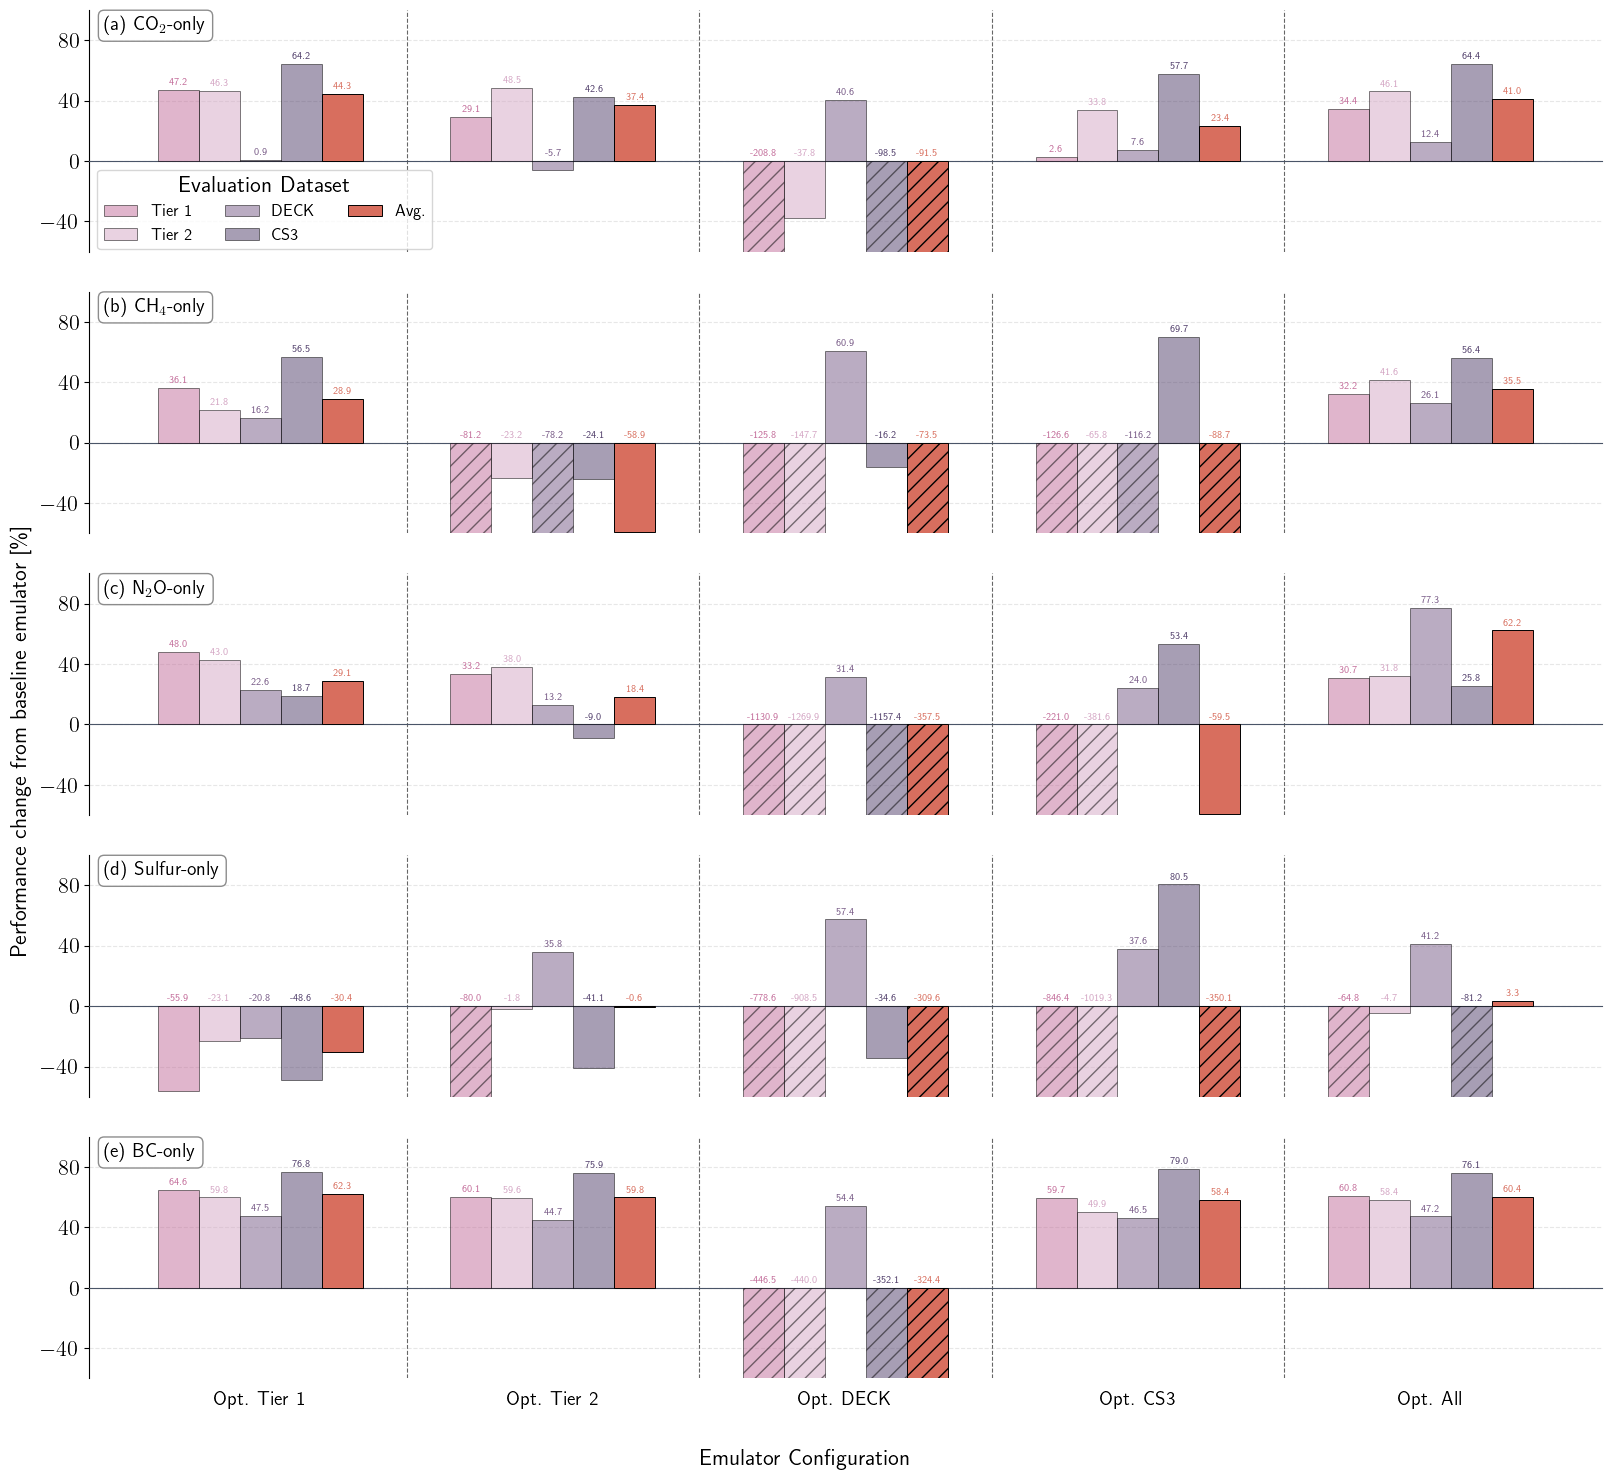

In [153]:
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3']
weights = [7, 5, 2, 2]
utils_plotting.plot_vertical_stacked_bars(baseline_results_list,
                               optimal_results_list,
                               train_scenarios,
                               test_scenarios,
                               weights,
                               titles=None,
                               save=False,
                               figname='SI_extended_results')